In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from supermops.models import FourierNDModel, DynamicSuperresModel
from supermops.discretization import Discretization
from supermops.generators import *
from supermops.eval import cluster_weights, match_sources
from supermops.solvers import SeparableConeSolver
from supermops.utils import announce_save
from supermops.plotting import *

In [2]:
# static parameters
fc = 3  # frequency cutoff
# static model
model_static = FourierNDModel([np.arange(-fc, fc + 1), np.arange(-fc, fc + 1)])

# dynamic parameters
K = 1  # time steps -K, -K+1, ..., K
dt = 1  # time span between adjacent steps
model = DynamicSuperresModel(model_static, K, dt)

# define ground truth
support = np.array([[0.5, 0.47, 0.2, 0.0], [0.5, 0.53, -0.2, 0.0]])
weights = np.array([1.0, 1.0])
support, weights = uniform_stay_in_square(K, dt, min_num_srcs=2, max_num_srcs=5)

target = model.apply(support, weights)
# optionally add noise
#target += 0.2*np.random.randn(*target.shape)

l1_target = np.linalg.norm(weights, ord=1)

disc = Discretization(
    K=K,
    dt=dt,
    num_mu_dirs=5,  # number of directions for var mu
    num_extra_nu_dirs=2,  # number of directions for var nu (+ time dirs)
    num_rads=100,  # number of grid points for projections
    grid_size_nu=100,  # num of grid points along one axis for nu
    grid_size_mu=100,  # num of grid points along one axis for mu
    adaptive_grids=True,  # whether to generate new grids for each var
)

In [3]:
if False:
    mu, nu = np.load("sol.npy", allow_pickle=True)
else:
    print("Stage 1: Main objective")
    Msys, rhs = disc.build_main_objective(model_static, target)
    solver = SeparableConeSolver(disc, Msys, rhs, l1_target, nonneg=False)

    print("Start opt...")
    start = time.time()
    mu, nu = solver.solve()
    end = time.time()
    print("Finished opt in {:.2f} secs.".format(end - start))

    announce_save("sol", (mu, nu), "solution")

Stage 1: Main objective
Building mu radon mats: 1/5
Building mu radon mats: 2/5
Building mu radon mats: 3/5
Building mu radon mats: 4/5
Building mu radon mats: 5/5
Building nu radon mats: 1/5
Building nu radon mats: 2/5
Building nu radon mats: 3/5
Building nu radon mats: 4/5
Building nu radon mats: 5/5
Building Msys...
Msys shape = (2794, 100000), nonzero = 3816585 (1.37%)
Start opt...
MOSEK warning 710: #103 (nearly) zero elements are specified in sparse col '' (200011) of matrix 'A'.
MOSEK warning 710: #110 (nearly) zero elements are specified in sparse col '' (200012) of matrix 'A'.
MOSEK warning 710: #102 (nearly) zero elements are specified in sparse col '' (200013) of matrix 'A'.
MOSEK warning 710: #109 (nearly) zero elements are specified in sparse col '' (200014) of matrix 'A'.
MOSEK warning 710: #110 (nearly) zero elements are specified in sparse col '' (200015) of matrix 'A'.
MOSEK warning 710: #111 (nearly) zero elements are specified in sparse col '' (200016) of matrix 'A'.

In [4]:
detected = []
for k in range(-K, K+1):
    detected.append(cluster_weights(disc.nu_sol_for_time(nu, k)))

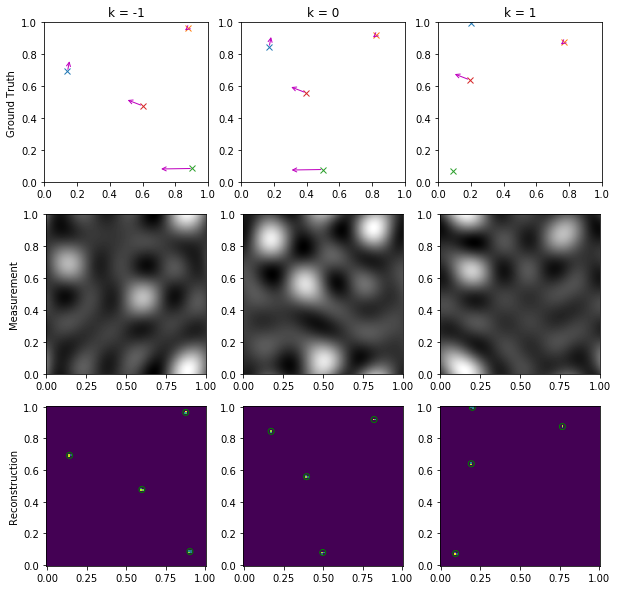

In [5]:
#%matplotlib tk
plot_fourier_vis(support, weights, disc, fc, nu, detected)
plt.show()

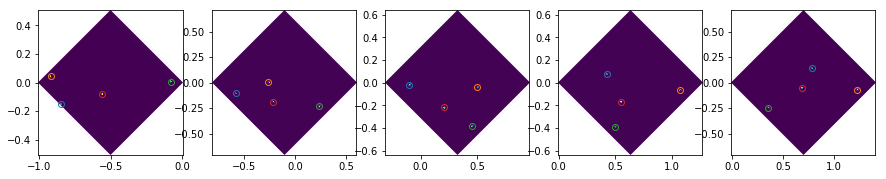

In [6]:
#%matplotlib tk
fig, axs = plt.subplots(1, disc.num_mu_dirs, figsize=(15,45))
plot_all_mu_sols(axs, disc, support, mu)
plt.show()

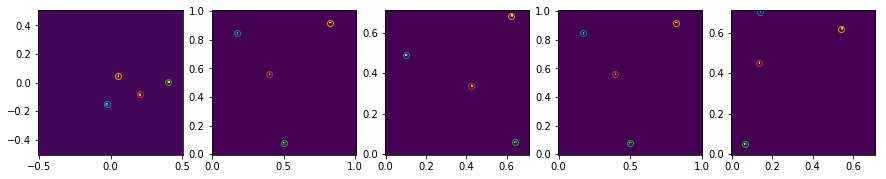

In [7]:
fig, axs = plt.subplots(1, disc.num_total_nu_dirs, figsize=(15,45))
plot_all_nu_sols(axs, disc, support, nu)
plt.show()